## Melih Yelman - 21011702 - Veri Madenciliği - Proje

In [ ]:
!pip install pycaret shap pycaret[analysis] werkzeug pandas matplotlib seaborn scikit-learn

# A) Veri Analizi

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering

In [ ]:
# Veri setini yükleme
df = pd.read_csv('kr-vs-kp.data', header=None)

# Doğru sütun isimlerini tanımla
column_names = [
    'bkblk', 'bknwy', 'bkon8', 'bkona', 'bkspr', 'bkxbq', 'bkxcr', 'bkxwp',
    'blxwp', 'bxqsq', 'cntxt', 'dsopp', 'dwipd', 'hdchk', 'katri', 'mulch',
    'qxmsq', 'r2ar8', 'reskd', 'reskr', 'rimmx', 'rkxwp', 'rxmsq', 'simpl',
    'skach', 'skewr', 'skrxp', 'spcop', 'stlmt', 'thrsk', 'wkcti', 'wkna8',
    'wknck', 'wkovl', 'wkpos', 'wtoeg', 'class'
]

# Sütun isimlerini ata
df.columns = column_names

## Veri Seti İçeriği ve Bilgiler

In [4]:
# Veri setinin ilk 5 satırını göster
df.head()

,bkblk,bknwy,bkon8,bkona,bkspr,bkxbq,bkxcr,bkxwp,blxwp,bxqsq,...,spcop,stlmt,thrsk,wkcti,wkna8,wknck,wkovl,wkpos,wtoeg,class
0,f,f,f,f,f,f,f,f,f,f,...,f,f,f,f,f,f,t,t,n,won
1,f,f,f,f,t,f,f,f,f,f,...,f,f,f,f,f,f,t,t,n,won
2,f,f,f,f,t,f,t,f,f,f,...,f,f,f,f,f,f,t,t,n,won
3,f,f,f,f,f,f,f,f,t,f,...,f,f,f,f,f,f,t,t,n,won
4,f,f,f,f,f,f,f,f,f,f,...,f,f,f,f,f,f,t,t,n,won


In [5]:
# Veri seti hakkında genel bilgi
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3196 entries, 0 to 3195
Data columns (total 37 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   bkblk   3196 non-null   object
 1   bknwy   3196 non-null   object
 2   bkon8   3196 non-null   object
 3   bkona   3196 non-null   object
 4   bkspr   3196 non-null   object
 5   bkxbq   3196 non-null   object
 6   bkxcr   3196 non-null   object
 7   bkxwp   3196 non-null   object
 8   blxwp   3196 non-null   object
 9   bxqsq   3196 non-null   object
 10  cntxt   3196 non-null   object
 11  dsopp   3196 non-null   object
 12  dwipd   3196 non-null   object
 13  hdchk   3196 non-null   object
 14  katri   3196 non-null   object
 15  mulch   3196 non-null   object
 16  qxmsq   3196 non-null   object
 17  r2ar8   3196 non-null   object
 18  reskd   3196 non-null   object
 19  reskr   3196 non-null   object
 20  rimmx   3196 non-null   object
 21  rkxwp   3196 non-null   object
 22  rxmsq   3196 non-null   

Sınıf dağılımı:
class
won      1669
nowin    1527
Name: count, dtype: int64

Beyaz kazanma oranı: 52.22%
Beyaz kazanamama oranı: 47.78%


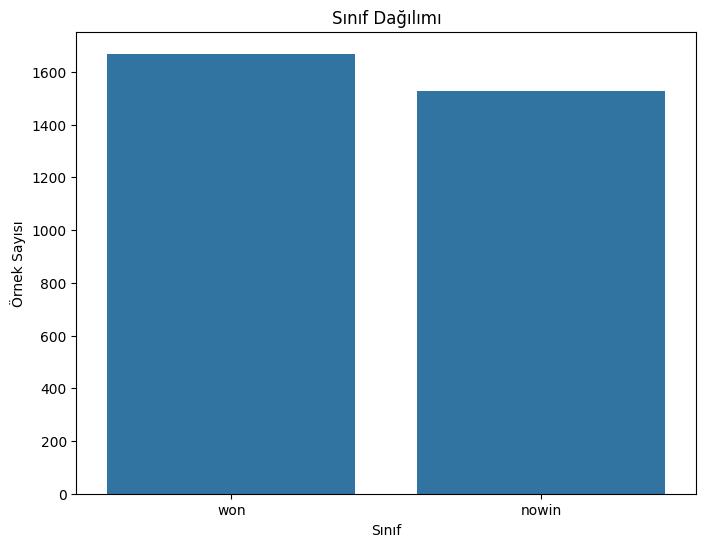

In [6]:
# Sınıf dağılımını göster
class_counts = df['class'].value_counts()
print(f"Sınıf dağılımı:\n{class_counts}")
print(f"\nBeyaz kazanma oranı: {class_counts['won']/len(df)*100:.2f}%")
print(f"Beyaz kazanamama oranı: {class_counts['nowin']/len(df)*100:.2f}%")

plt.figure(figsize=(8, 6))
sns.countplot(x='class', data=df)
plt.title('Sınıf Dağılımı')
plt.xlabel('Sınıf')
plt.ylabel('Örnek Sayısı')
plt.show()

## Eksik Veri Analizi

In [7]:
# Eksik veri kontrolü
missing_data = df.isnull().sum()

if missing_data.sum() > 0:
    # Eksik veri varsa görselleştir
    plt.figure(figsize=(10, 6))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title('Eksik Veri Haritası')
    plt.show()
else:
    print("\nVeri setinde eksik veri bulunmamaktadır.")


Veri setinde eksik veri bulunmamaktadır.


## Aykırı Değer Analizi

In [8]:
threshold = 0.01   # %1’in altındaki kategoriler rare olsun

categorical_cols = df.select_dtypes(include=['object']).columns
rare_categories = {}

for col in categorical_cols:
    freqs = df[col].value_counts(normalize=True)
    rares = freqs[freqs < threshold].index.tolist()
    if rares:
        rare_categories[col] = rares
        print(f"{col}: nadir kategoriler → {rares}")

hdchk: nadir kategoriler → ['t']
reskd: nadir kategoriler → ['t']
skach: nadir kategoriler → ['t']
spcop: nadir kategoriler → ['t']


## Öznitelik Önem Analizi

In [9]:
from scipy.stats import chi2_contingency
# Özniteliklerin sınıflara göre dağılımı için görselleştirme
important_features = []

for col in df.columns:
    if col != 'class' and df[col].nunique() > 1:
        # Ki-kare testi ile özniteliklerin ayrıştırma gücünü hesaplama
        contingency_table = pd.crosstab(df[col], df['class'])
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        important_features.append((col, chi2, p_value))

# Öznitelik önemine göre sıralama
important_features.sort(key=lambda x: x[1], reverse=True)
print("\nÖzniteliklerin sınıflandırmadaki önem sıralaması (Ki-kare testi):")
for feature, chi2_value, p_value in important_features:
    print(f"{feature}: Chi2 = {chi2_value:.2f}, p-value = {p_value:.10f}")


Özniteliklerin sınıflandırmadaki önem sıralaması (Ki-kare testi):
rimmx: Chi2 = 651.44, p-value = 0.0000000000
bxqsq: Chi2 = 460.10, p-value = 0.0000000000
wknck: Chi2 = 424.90, p-value = 0.0000000000
bkxwp: Chi2 = 172.24, p-value = 0.0000000000
katri: Chi2 = 154.27, p-value = 0.0000000000
wkna8: Chi2 = 121.75, p-value = 0.0000000000
r2ar8: Chi2 = 85.80, p-value = 0.0000000000
bkxcr: Chi2 = 85.10, p-value = 0.0000000000
mulch: Chi2 = 78.66, p-value = 0.0000000000
wkpos: Chi2 = 67.97, p-value = 0.0000000000
bkxbq: Chi2 = 61.90, p-value = 0.0000000000
skrxp: Chi2 = 53.27, p-value = 0.0000000000
wkcti: Chi2 = 50.36, p-value = 0.0000000000
stlmt: Chi2 = 50.03, p-value = 0.0000000000
rkxwp: Chi2 = 32.36, p-value = 0.0000000128
dwipd: Chi2 = 31.25, p-value = 0.0000000227
bkon8: Chi2 = 25.61, p-value = 0.0000004179
rxmsq: Chi2 = 23.89, p-value = 0.0000010220
blxwp: Chi2 = 22.83, p-value = 0.0000017657
cntxt: Chi2 = 14.56, p-value = 0.0001358635
hdchk: Chi2 = 14.44, p-value = 0.0001449688
sim

# B) Sınıflama

In [10]:
from pycaret.classification import *

In [11]:
# Sınıflandırma için veri setini hazırlama
setup = setup(
    df,
    target='class',
    session_id=21011702,
    fold_shuffle=True,
    fold = 10,
    remove_multicollinearity=True,
    multicollinearity_threshold=0.90,
    verbose=False
)

In [12]:
# Model karşılaştırması
top_3_models = compare_models(sort='F1', n_select=3, exclude=['lightgbm'], turbo=False)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dt,Decision Tree Classifier,0.9946,0.9945,0.9946,0.9947,0.9946,0.9893,0.9893,0.0960
xgboost,Extreme Gradient Boosting,0.9928,0.9996,0.9928,0.9929,0.9928,0.9857,0.9858,0.2150
et,Extra Trees Classifier,0.9924,0.9980,0.9924,0.9925,0.9924,0.9848,0.9849,0.1580
mlp,MLP Classifier,0.9920,0.9991,0.9920,0.9920,0.9920,0.9839,0.9839,0.5560
rf,Random Forest Classifier,0.9879,0.9984,0.9879,0.9881,0.9879,0.9758,0.9759,0.1570
gbc,Gradient Boosting Classifier,0.9763,0.9978,0.9763,0.9765,0.9763,0.9526,0.9527,0.1440
gpc,Gaussian Process Classifier,0.9727,0.9968,0.9727,0.9729,0.9727,0.9453,0.9455,3.7130
svm,SVM - Linear Kernel,0.9674,0.9947,0.9674,0.9677,0.9674,0.9346,0.9349,0.0980
ada,Ada Boost Classifier,0.9656,0.9954,0.9656,0.9661,0.9655,0.9309,0.9315,0.1200
lr,Logistic Regression,0.9602,0.9930,0.9602,0.9604,0.9602,0.9203,0.9204,0.7030


Processing:   0%|          | 0/75 [00:00<?, ?it/s]


1. En İyi Model: DecisionTreeClassifier

1 Confusion Matrix DecisionTreeClassifier


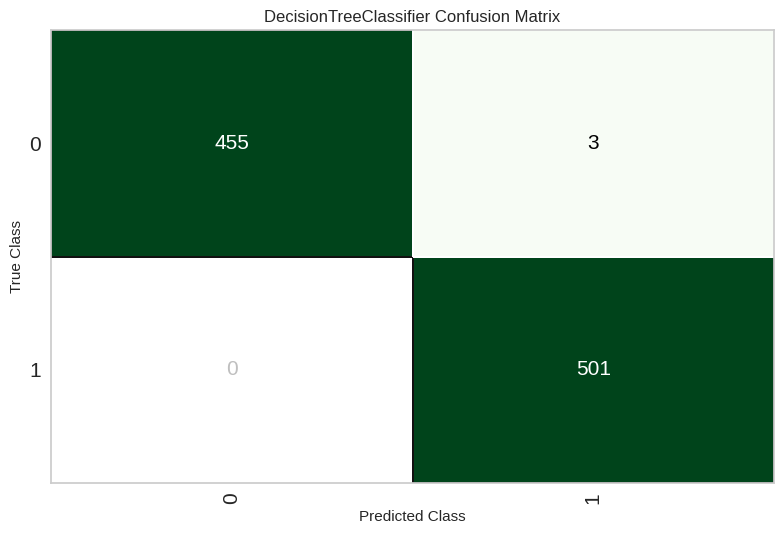


1 Feature DecisionTreeClassifier


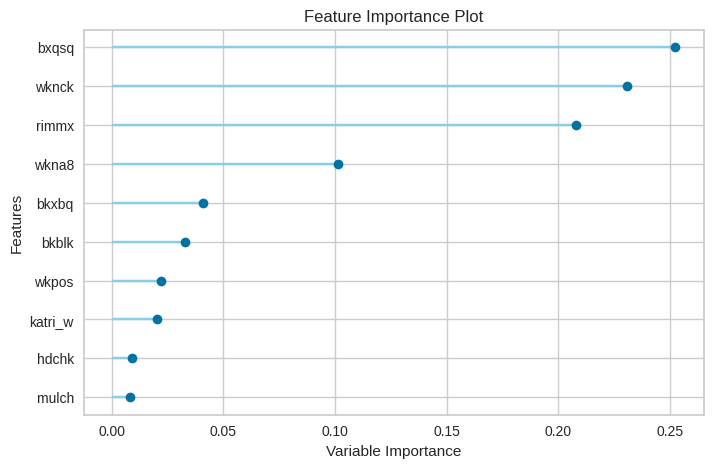


1 Class Report DecisionTreeClassifier


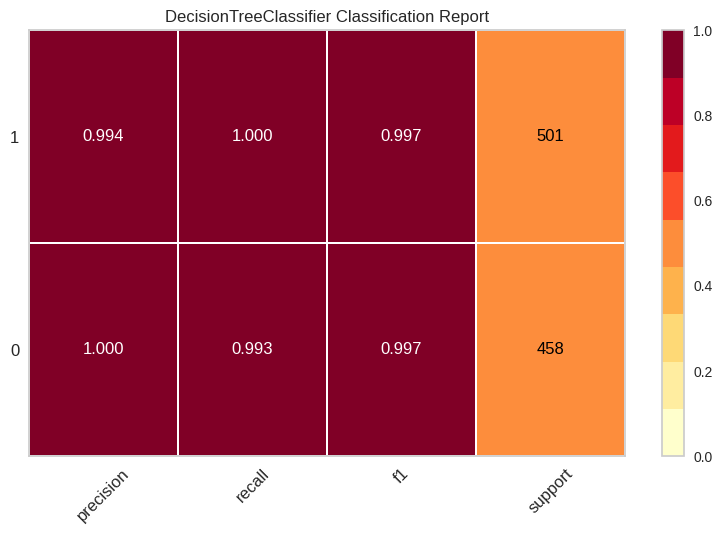


1 Pr DecisionTreeClassifier


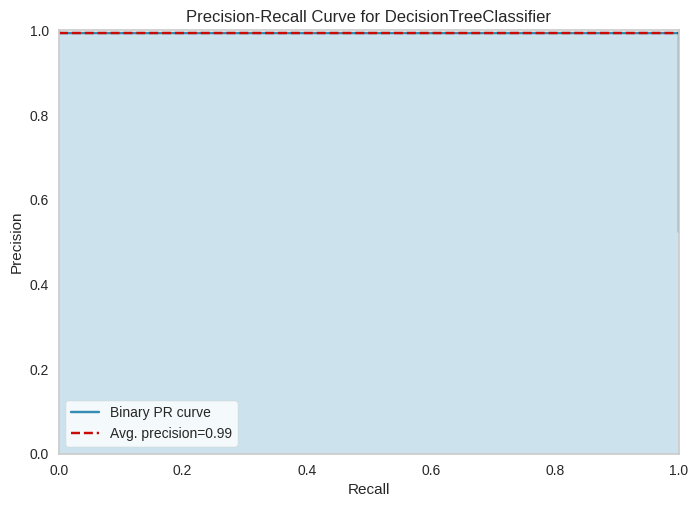


1 Auc DecisionTreeClassifier


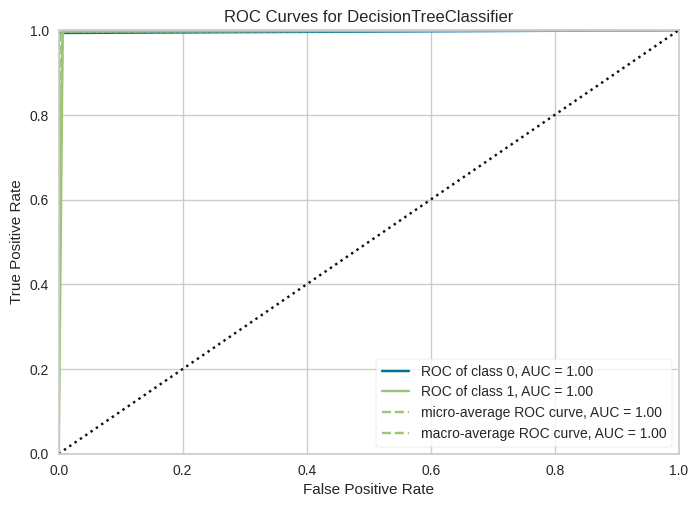


1 Test  DecisionTreeClassifier


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Decision Tree Classifier,0.9969,0.9967,0.9969,0.9969,0.9969,0.9937,0.9937



1 Interpret Model DecisionTreeClassifier


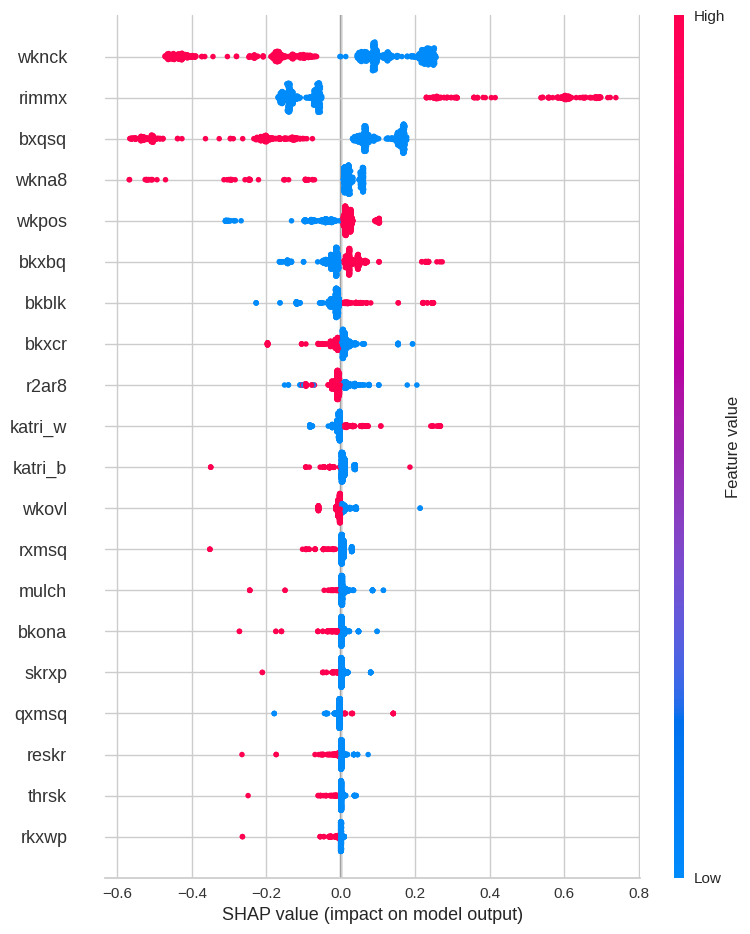


2. En İyi Model: XGBClassifier

2 Confusion Matrix XGBClassifier


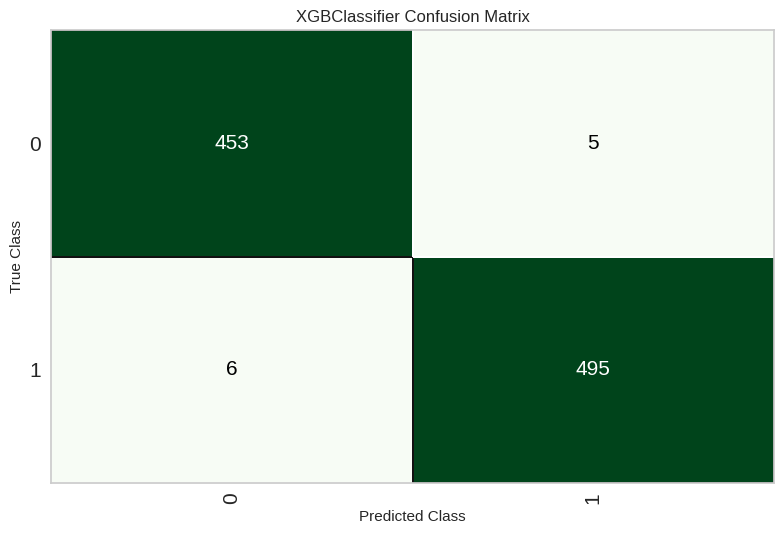


2 Feature XGBClassifier


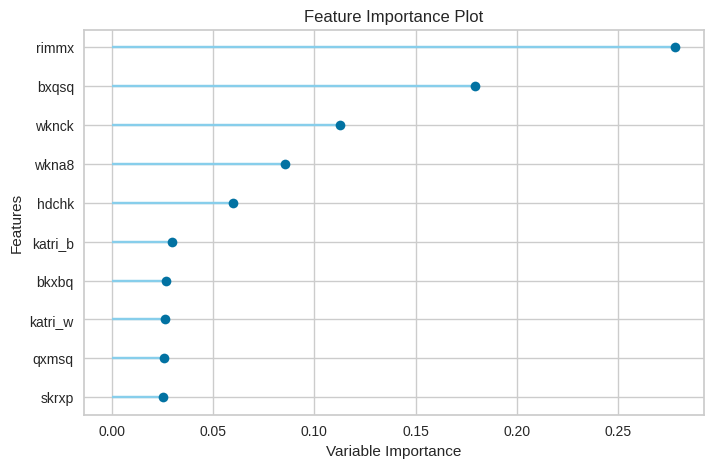


2 Class Report XGBClassifier


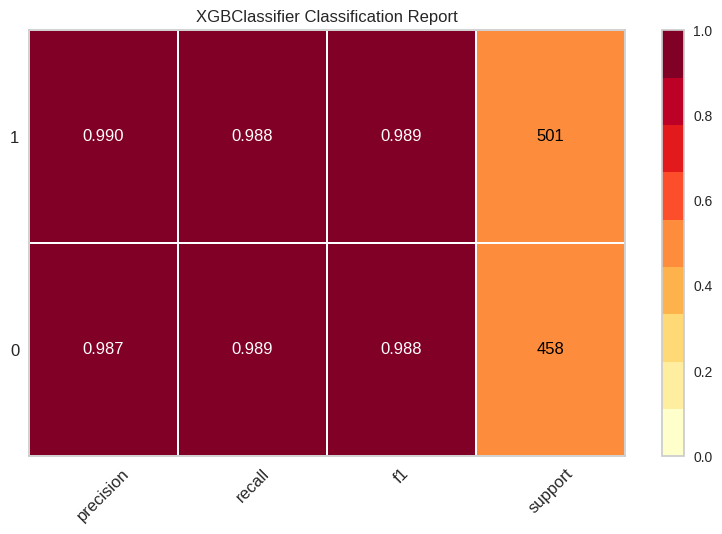


2 Pr XGBClassifier


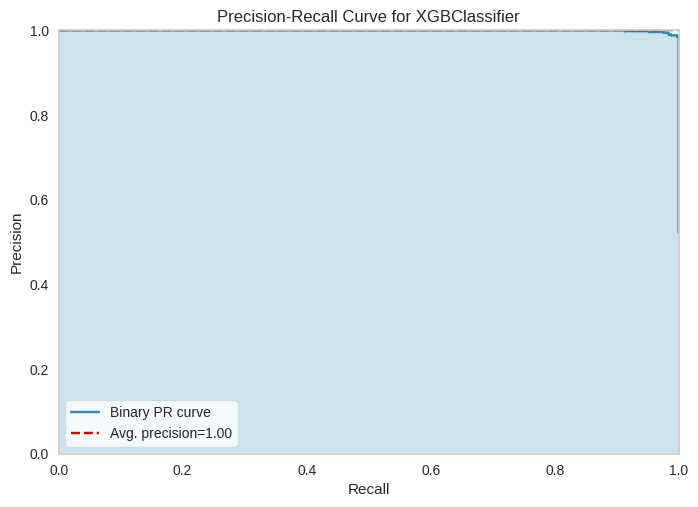


2 Auc XGBClassifier


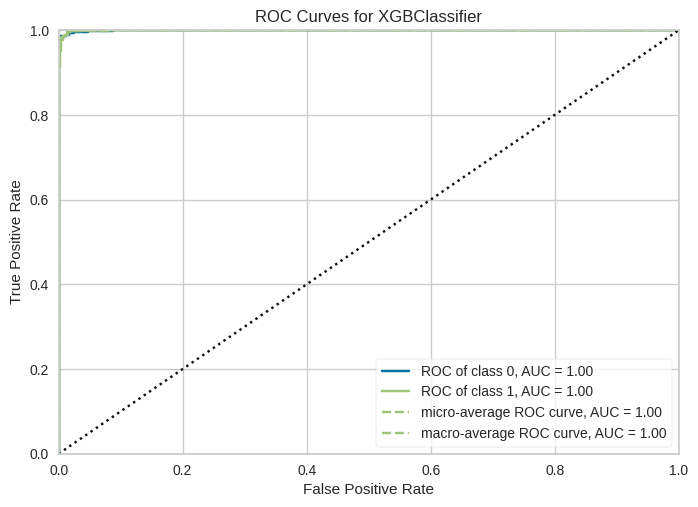


2 Test  XGBClassifier


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.9885,0.9995,0.9885,0.9885,0.9885,0.9770,0.9770



2 Interpret Model XGBClassifier


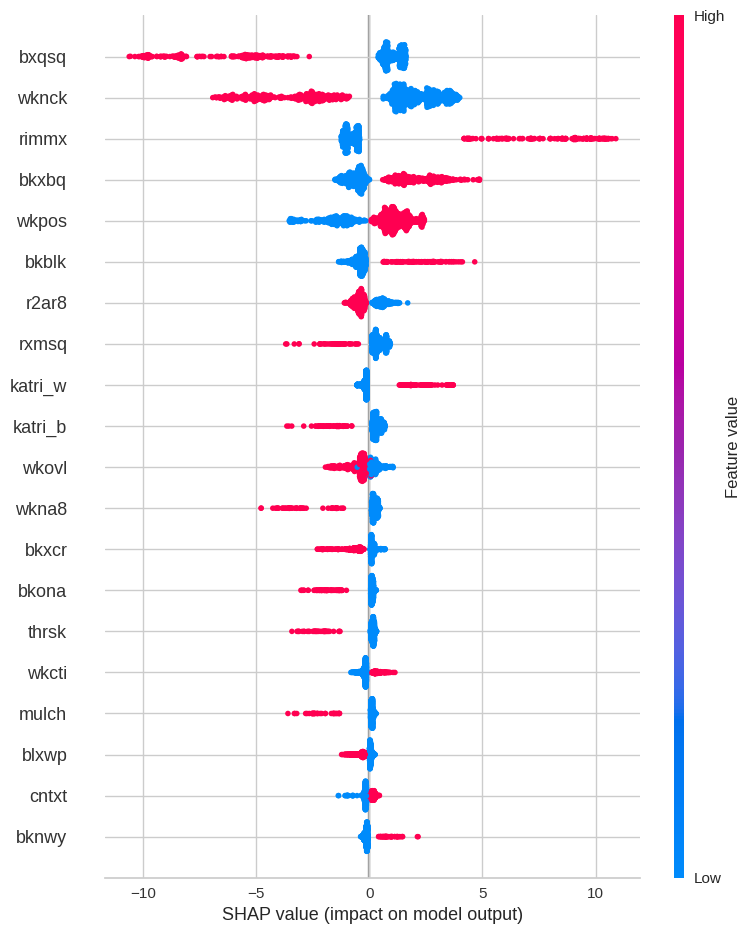


3. En İyi Model: ExtraTreesClassifier

3 Confusion Matrix ExtraTreesClassifier


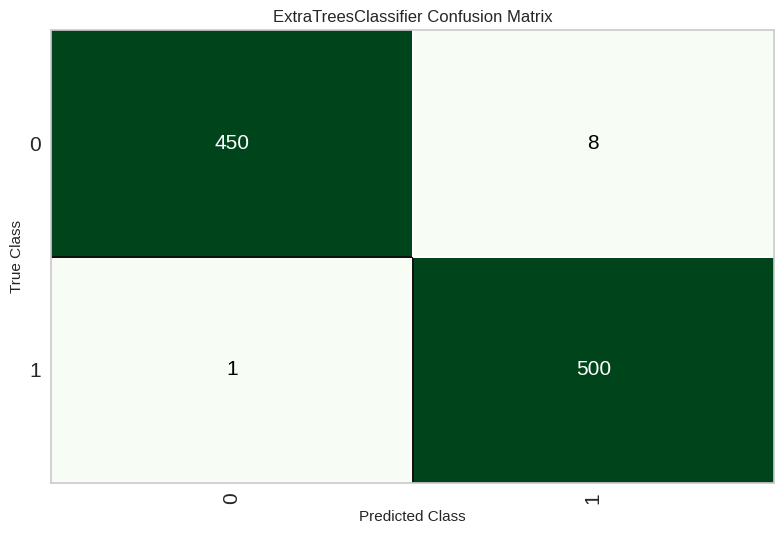


3 Feature ExtraTreesClassifier


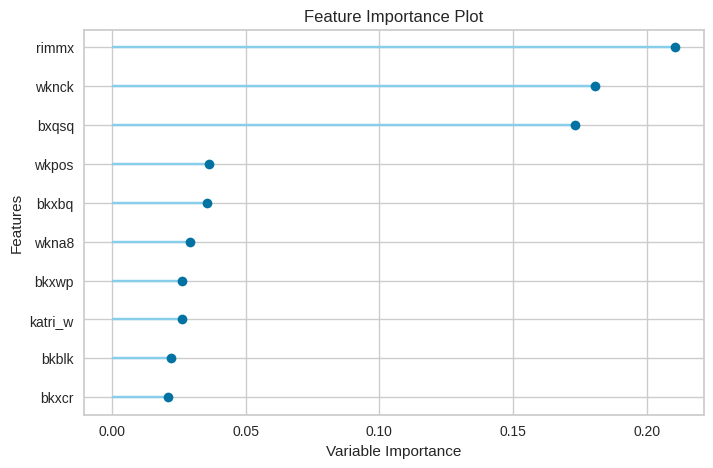


3 Class Report ExtraTreesClassifier


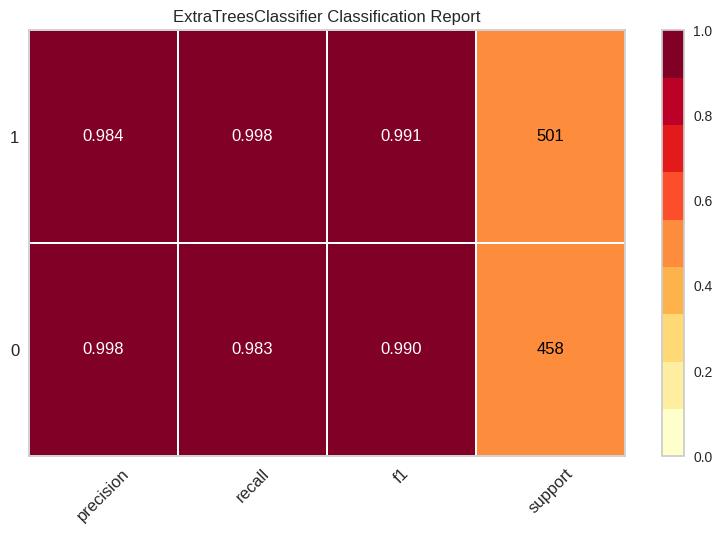


3 Pr ExtraTreesClassifier


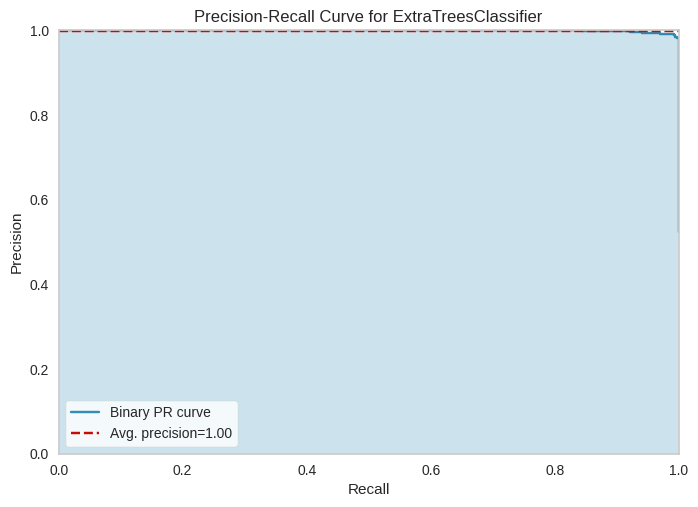


3 Auc ExtraTreesClassifier


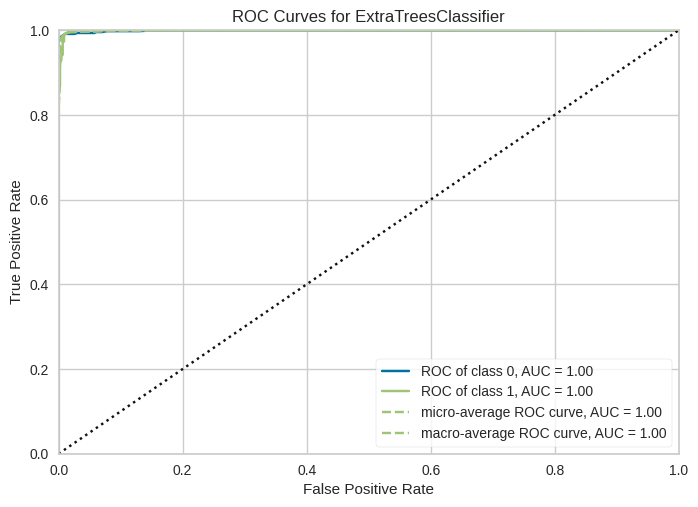


3 Test  ExtraTreesClassifier


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.9906,0.9993,0.9906,0.9907,0.9906,0.9812,0.9813



3 Interpret Model ExtraTreesClassifier


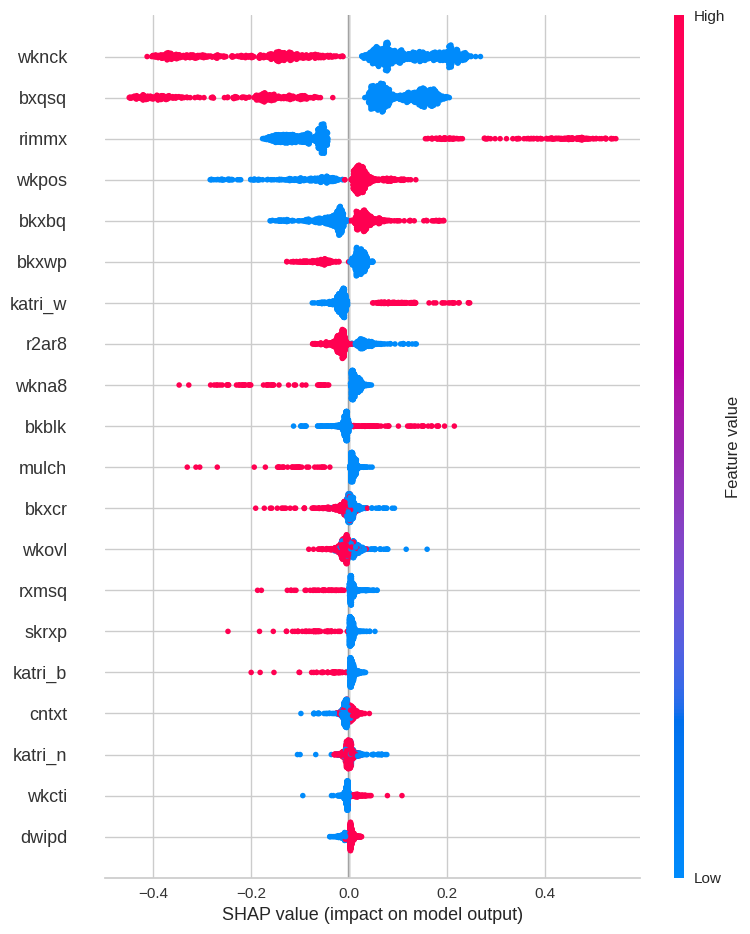

In [13]:
for i, model in enumerate(top_3_models, 1):
    print(f"\n{i}. En İyi Model: {model.__class__.__name__}")

    print(f"\n{i} Confusion Matrix {model.__class__.__name__}")
    plot_model(model, plot='confusion_matrix')
    print(f"\n{i} Feature {model.__class__.__name__}")
    plot_model(model, plot='feature')
    print(f"\n{i} Class Report {model.__class__.__name__}")
    plot_model(model, plot='class_report')
    print(f"\n{i} Pr {model.__class__.__name__}")
    plot_model(model, plot='pr')
    print(f"\n{i} Auc {model.__class__.__name__}")
    plot_model(model, plot='auc')
    print(f"\n{i} Test  {model.__class__.__name__}")
    holdout_pred = predict_model(model)

    print(f"\n{i} Interpret Model {model.__class__.__name__}")
    interpret_model(model)

# C) Kümeleme

In [14]:
# Kümeleme için veri hazırlama - target sütununu ayırma
df_numeric = df.copy()
categorical_cols = df_numeric.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df_numeric[col] = pd.factorize(df_numeric[col])[0]
X = df_numeric.drop('class', axis=1)
y = df_numeric['class']

In [15]:
# Veriyi standardize etme
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
# PCA uygulama (görselleştirme için)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

## Kümeleme Yöntemleri ve Karşılaştırma
### Kümeleme Algoritmalarının Seçimi

KMeans ve Agglomerative Clustering, veri madenciliğinde sıkça kullanılan temel kümeleme yöntemlerindendir. Spectral Clustering ise, lineer olmayan yapıdaki kümeleri de tespit edebilme potansiyeline sahip olduğu için eklenmiştir.


In [17]:
# 1. K-Means Kümeleme (k=2, veri setinde 2 sınıf olduğu için)
kmeans = KMeans(n_clusters=2, random_state=123, n_init=10)
kmeans_clusters = kmeans.fit_predict(X_scaled)

# 2. Hiyerarşik Kümeleme
hierarchical = AgglomerativeClustering(n_clusters=2)
hierarchical_clusters = hierarchical.fit_predict(X_scaled)

# 3. Spectral Clustering
spectral = SpectralClustering(n_clusters=2, random_state=123, affinity='nearest_neighbors')
spectral_clusters = spectral.fit_predict(X_scaled)


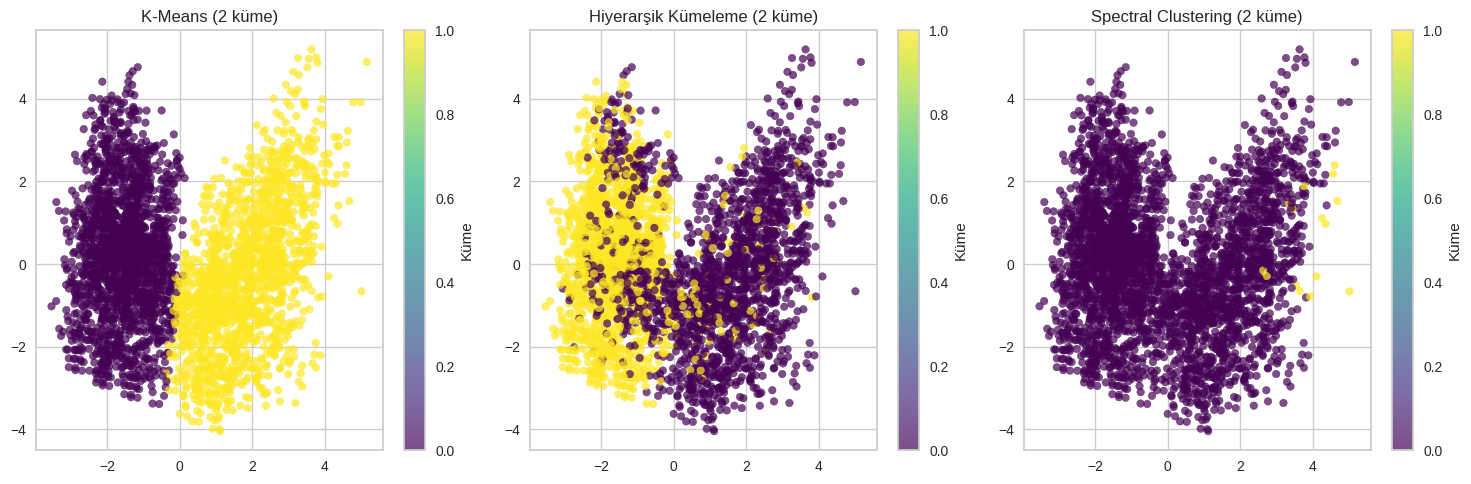

In [18]:
# Kümeleme sonuçlarını görselleştirme ve değerlendirme
plt.figure(figsize=(15, 5))

# K-Means
plt.subplot(1, 3, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_clusters, cmap='viridis', s=30, alpha=0.7)
plt.title('K-Means (2 küme)')
plt.colorbar(label='Küme')

# Hierarchical
plt.subplot(1, 3, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hierarchical_clusters, cmap='viridis', s=30, alpha=0.7)
plt.title('Hiyerarşik Kümeleme (2 küme)')
plt.colorbar(label='Küme')

# Spectral Clustering
plt.subplot(1, 3, 3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=spectral_clusters, cmap='viridis', s=30, alpha=0.7)
plt.title('Spectral Clustering (2 küme)')
plt.colorbar(label='Küme')

plt.tight_layout()
plt.show()

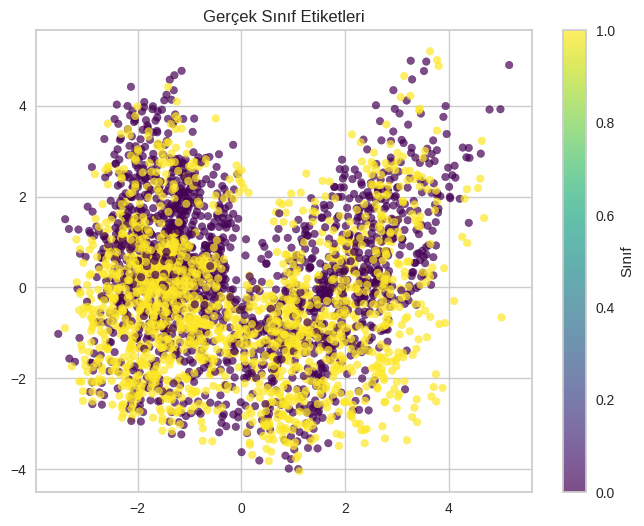

In [19]:
# Gerçek sınıf etiketleri ile karşılaştırma
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=30, alpha=0.7)
plt.title('Gerçek Sınıf Etiketleri')
plt.colorbar(label='Sınıf')
plt.show()

In [20]:
# Küme sayıları
kmeans_counts = pd.Series(kmeans_clusters).value_counts().sort_index()
hierarchical_counts = pd.Series(hierarchical_clusters).value_counts().sort_index()
spectral_counts = pd.Series(spectral_clusters).value_counts().sort_index()

print("K-Means küme dağılımı:")
print(kmeans_counts)
print("\nHiyerarşik küme dağılımı:")
print(hierarchical_counts)
print("\nSpectral Clustering küme dağılımı:")
print(spectral_counts)

K-Means küme dağılımı:
0    1733
1    1463
Name: count, dtype: int64

Hiyerarşik küme dağılımı:
0    1728
1    1468
Name: count, dtype: int64

Spectral Clustering küme dağılımı:
0    3181
1      15
Name: count, dtype: int64


In [ ]:
# Kümeleme performansını değerlendirme
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, accuracy_score

ari_scores = []
nmi_scores = []
accuracy_scores = []

for name, labels in zip(["KMeans", "Hierarchical", "Spectral"], [kmeans_clusters, hierarchical_clusters, spectral_clusters]):
    ari = adjusted_rand_score(y, labels)
    nmi = normalized_mutual_info_score(y, labels)
    ari_scores.append(ari)
    nmi_scores.append(nmi)
    kmeans_accuracy = accuracy_score(y, kmeans_clusters)
    hierarchical_accuracy = accuracy_score(y, hierarchical_clusters)
    spectral_accuracy = accuracy_score(y, spectral_clusters)

    accuracy_scores = [kmeans_accuracy, hierarchical_accuracy, spectral_accuracy]

summary_df = pd.DataFrame({
    "Yöntem": ["KMeans", "Hierarchical", "Spectral"],
    "Accuracy": accuracy_scores,
    "ARI": ari_scores,
    "NMI": nmi_scores
})
print(summary_df)


         Yöntem  Accuracy       ARI       NMI
0        KMeans  0.515019  0.000578  0.000505
1  Hierarchical  0.452128  0.008847  0.007221
2      Spectral  0.526909  0.000955  0.009636


# Genel Değerlendirme

## Sınıflandırma Algoritmaları için:

Veri seti üzerinde uygulanan çeşitli sınıflandırma algoritmaları %90'ın üzerinde doğruluk oranı ile oldukça yüksek bir performans sergilemiştir. En iyi üç modelin F1 skorları %98 seviyesine ulaşmış ve hata payı neredeyse yok denecek kadar azdır. Bu, veri setindeki sınıf ayrımının gözetimli öğrenme yöntemleriyle kolaylıkla tespit edilebildiğini göstermektedir. Özellikle pycaret kullanılarak yapılan model karşılaştırması sonucu, veri setinin özelliklerinin sınıflandırma açısından ayırt ediciliğinin yüksek olduğu anlaşılmaktadır.

Kullanılan modellerin her biri, karmaşık ilişkileri ve özellik etkileşimlerini başarıyla öğrenebilmiştir. Sınıf karışıklık matrisleri incelendiğinde yanlış sınıflandırılan örnek sayısının oldukça düşük olduğu görülmektedir. Bu da hem veri setinin, hem de seçilen sınıflandırma algoritmalarının uygunluğunu ortaya koymaktadır.

## Kümeleme Yöntemleri için:

Uygulanan kümeleme algoritmaları (KMeans, Hiyerarşik/Agglomerative Clustering ve Spectral Clustering) ise veri setindeki gerçek sınıf yapısını yakalamada başarısız olmuştur. Özellikle accuracy, ARI (Adjusted Rand Index) ve NMI (Normalized Mutual Information) gibi değerlendirme metriklerinin tümünde skorlar %50 civarında kalmış veya sıfıra yakın değerler almıştır. Bu skorlar, rastgele bir atama ile elde edilebilecek seviyeye oldukça yakındır.

Spectral Clustering yöntemi, veri noktalarının büyük çoğunluğunu tek bir kümede toplamış ve ayrım yapmada en kötü sonucu vermiştir. KMeans ve Agglomerative Clustering yöntemlerinde ise kümeler daha dengeli dağılmış olsa da, bu dağılım gerçek sınıf etiketleri ile örtüşmemiştir.

Bu sonuçlar, satranç pozisyonlarından oluşan bu veri setinin özellikleri arasındaki ilişkilerin karmaşıklığı ve sınıflar arası ayrımın lineer olmaması nedeniyle gözetimsiz öğrenme yöntemleriyle başarılı şekilde çözümlenemediğini göstermektedir. Kümeleme algoritmaları, verinin doğal yapısını ortaya çıkarmak için genellikle veri setinin daha basit, homojen ve iyi ayrılmış olmasını gerektirir. Bu tür karmaşık, kategorik ve çok boyutlu veri setlerinde klasik kümeleme algoritmaları yetersiz kalabilmektedir.

---

### Sonuç

Bu projede, sınıflandırma algoritmaları ile çok yüksek doğruluk oranları elde edilirken, kümeleme algoritmalarının gerçek sınıf yapısını ortaya çıkarmakta yetersiz kaldığı gözlemlenmiştir. Bu durum, gözetimli ve gözetimsiz öğrenme yöntemlerinin güçlü ve zayıf yönlerinin pratikteki bir örneği olarak değerlendirilebilir.
